# Date-to-Date Debris Detection Results

Analyze XGBoost track classifier + CNN debris segmenter results across all zones and dates.
Shows how many avalanche paths were detected per cycle and the size/distribution of debris.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import MultiPolygon

from sarvalanche.io.dataset import load_netcdf_to_dataset
from sarvalanche.ml.track_classifier import _discover_run_files, zone_from_path
from sarvalanche.utils.raster_utils import _y_slice
from sarvalanche.utils.vector_utils import reproject_geom

# ── Paths ─────────────────────────────────────────────────────────────────
BASE = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw')
PRED_PATH = BASE / 'all_track_predictions.json'
SEG_PATH  = BASE / 'seg_features.parquet'
DEBRIS_GPKG = BASE / 'debris_shapes.gpkg'
RUNS_DIRS = [
    BASE / 'high_danger_output' / 'sarvalanche_runs',
    BASE / 'low_danger_output'  / 'sarvalanche_runs',
]

THRESHOLD = 0.5  # p_debris classification threshold

ZONE_SHORT = {
    'Banner_Summit': 'Banner',
    'Galena_Summit_&_Eastern_Mtns': 'Galena/East',
    'Sawtooth_&_Western_Smoky_Mtns': 'Sawtooth/West',
    'Soldier_&_Wood_River_Valley_Mtns': 'Soldier/Wood',
}

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

/Users/zmhoppinen/miniforge3/envs/sarvalanche/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load & parse predictions ─────────────────────────────────────────────
with open(PRED_PATH) as f:
    raw = json.load(f)

rows = []
for key, val in raw.items():
    zone, date_str, idx = key.split('|')
    rows.append({
        'key': key,
        'zone': zone,
        'date': pd.Timestamp(date_str),
        'track_idx': int(idx),
        'p_debris': val['p_debris'],
        'danger': val['danger'],
    })

df = pd.DataFrame(rows)
df['is_debris'] = df['p_debris'] >= THRESHOLD
df['zone_short'] = df['zone'].map(ZONE_SHORT)

# Join seg features
seg = pd.read_parquet(SEG_PATH)
df = df.merge(seg, left_on='key', right_index=True, how='left')

seg_coverage = df['seg_debris_fraction'].notna().mean()
print(f'Tracks: {len(df):,}  |  Debris: {df["is_debris"].sum():,} ({df["is_debris"].mean():.1%})')
print(f'Seg feature coverage: {seg_coverage:.1%}')
print(f'Zones: {sorted(df["zone"].unique())}')
print(f'Dates: {sorted(df["date"].unique())}')
df.head()

Tracks: 130,801  |  Debris: 78,351 (59.9%)
Seg feature coverage: 100.0%
Zones: ['Banner_Summit', 'Galena_Summit_&_Eastern_Mtns', 'Sawtooth_&_Western_Smoky_Mtns', 'Soldier_&_Wood_River_Valley_Mtns']
Dates: [Timestamp('2022-12-12 00:00:00'), Timestamp('2023-02-17 00:00:00'), Timestamp('2023-03-13 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2023-12-28 00:00:00'), Timestamp('2024-01-12 00:00:00'), Timestamp('2024-02-05 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-12-29 00:00:00'), Timestamp('2025-02-04 00:00:00'), Timestamp('2025-02-19 00:00:00')]


,key,zone,date,track_idx,p_debris,danger,is_debris,zone_short,seg_debris_fraction,seg_mean_prob,seg_max_prob,seg_p90_prob,seg_compactness,seg_top_ratio,seg_mid_ratio,seg_bot_ratio
0,Banner_Summit|2022-12-12|0,Banner_Summit,2022-12-12,0,0.7592,HIGH,True,Banner,0.001101,0.153019,0.511380,0.231893,0.012987,0.0,0.005362,0.000000
1,Banner_Summit|2022-12-12|1,Banner_Summit,2022-12-12,1,0.0223,HIGH,False,Banner,0.000000,0.128660,0.338132,0.187967,0.916667,0.0,0.000000,0.000000
2,Banner_Summit|2022-12-12|2,Banner_Summit,2022-12-12,2,0.2966,HIGH,False,Banner,0.000770,0.167268,0.531423,0.256581,1.000000,0.0,0.001905,0.000000
3,Banner_Summit|2022-12-12|3,Banner_Summit,2022-12-12,3,0.7421,HIGH,True,Banner,0.003733,0.133104,0.573069,0.223818,0.052632,0.0,0.001029,0.012069
4,Banner_Summit|2022-12-12|4,Banner_Summit,2022-12-12,4,0.7176,HIGH,True,Banner,0.000000,0.113575,0.477108,0.181706,0.000000,0.0,0.000000,0.000000


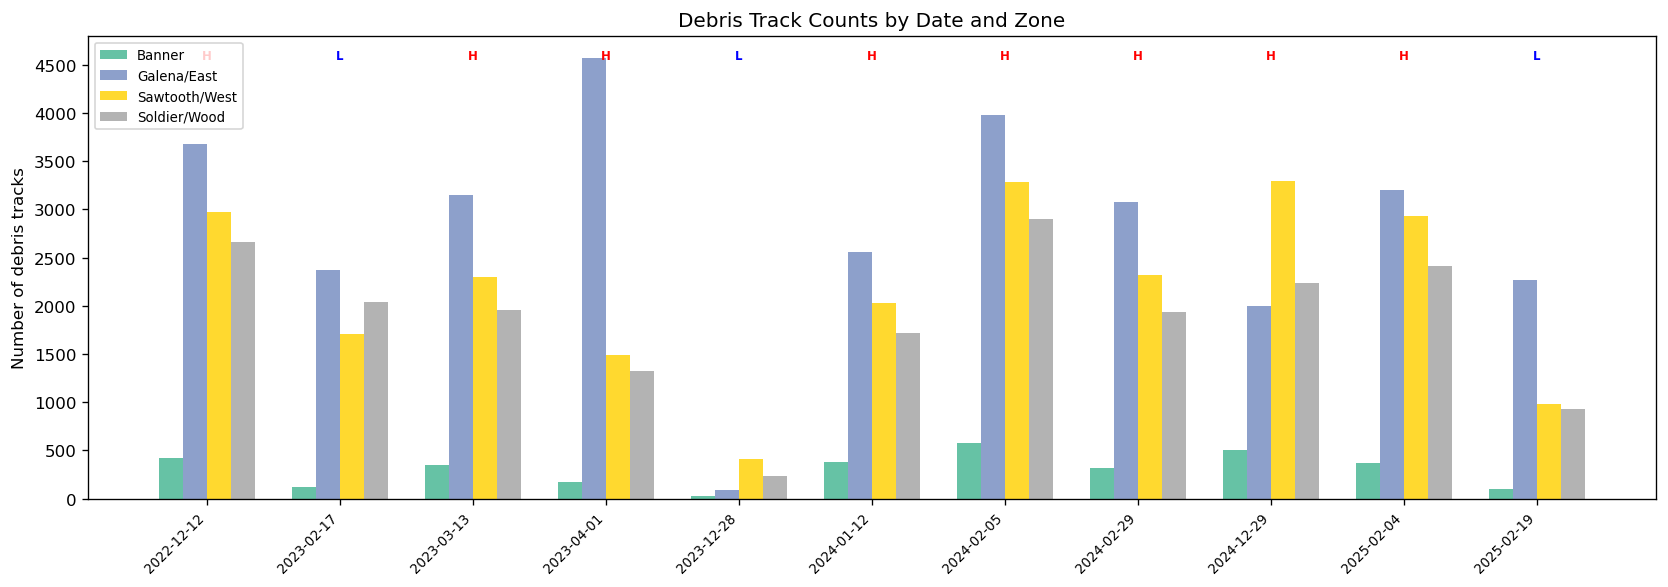

In [3]:
# ── Cell 3: Date-to-Date Track Counts ────────────────────────────────────
grp = df.groupby(['date', 'zone_short', 'danger']).agg(
    n_total=('is_debris', 'size'),
    n_debris=('is_debris', 'sum'),
).reset_index()
grp['debris_rate'] = grp['n_debris'] / grp['n_total']

zones = sorted(df['zone_short'].unique())
dates = sorted(df['date'].unique())
n_dates = len(dates)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n_dates)
width = 0.18
offsets = np.linspace(-width * (len(zones) - 1) / 2, width * (len(zones) - 1) / 2, len(zones))
colors = plt.cm.Set2(np.linspace(0, 1, len(zones)))

for i, zone in enumerate(zones):
    vals = []
    for d in dates:
        row = grp[(grp['date'] == d) & (grp['zone_short'] == zone)]
        vals.append(int(row['n_debris'].values[0]) if len(row) else 0)
    ax.bar(x + offsets[i], vals, width, label=zone, color=colors[i])

# Annotate danger level
for j, d in enumerate(dates):
    danger = df.loc[df['date'] == d, 'danger'].iloc[0]
    color = 'red' if danger == 'HIGH' else 'blue'
    ax.text(j, ax.get_ylim()[1] * 0.95, danger[0], ha='center', fontsize=7,
            fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in dates], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of debris tracks')
ax.set_title('Debris Track Counts by Date and Zone')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

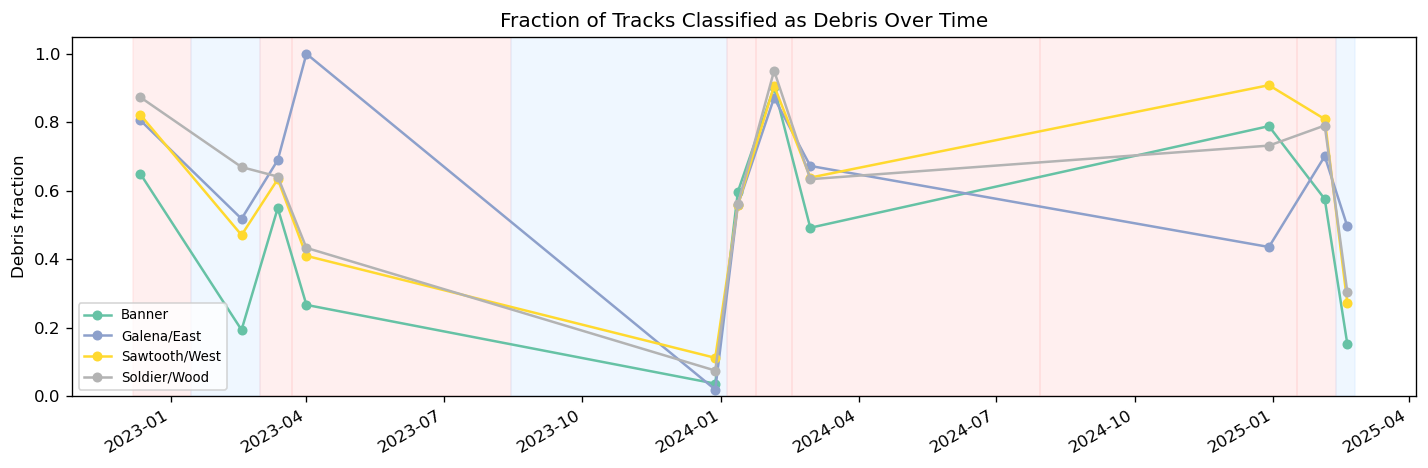

In [4]:
# ── Cell 4: Debris Fraction Over Time ────────────────────────────────────
frac = df.groupby(['date', 'zone_short', 'danger']).agg(
    debris_rate=('is_debris', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))

# Background shading for danger level
for j, d in enumerate(dates):
    danger = df.loc[df['date'] == d, 'danger'].iloc[0]
    c = '#ffcccc' if danger == 'HIGH' else '#cce5ff'
    if j == 0:
        left = d - pd.Timedelta(days=5)
    else:
        left = d - (d - dates[j - 1]) / 2
    if j == n_dates - 1:
        right = d + pd.Timedelta(days=5)
    else:
        right = d + (dates[j + 1] - d) / 2
    ax.axvspan(left, right, color=c, alpha=0.3, zorder=0)

for i, zone in enumerate(zones):
    sub = frac[frac['zone_short'] == zone].sort_values('date')
    ax.plot(sub['date'], sub['debris_rate'], 'o-', color=colors[i],
            label=zone, markersize=5, linewidth=1.5)

ax.set_ylabel('Debris fraction')
ax.set_title('Fraction of Tracks Classified as Debris Over Time')
ax.legend(fontsize=8)
ax.set_ylim(0, None)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Debris shapes loaded: 2363
Debris area range: 0 – 644759 m²


/Users/zmhoppinen/miniforge3/envs/sarvalanche/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


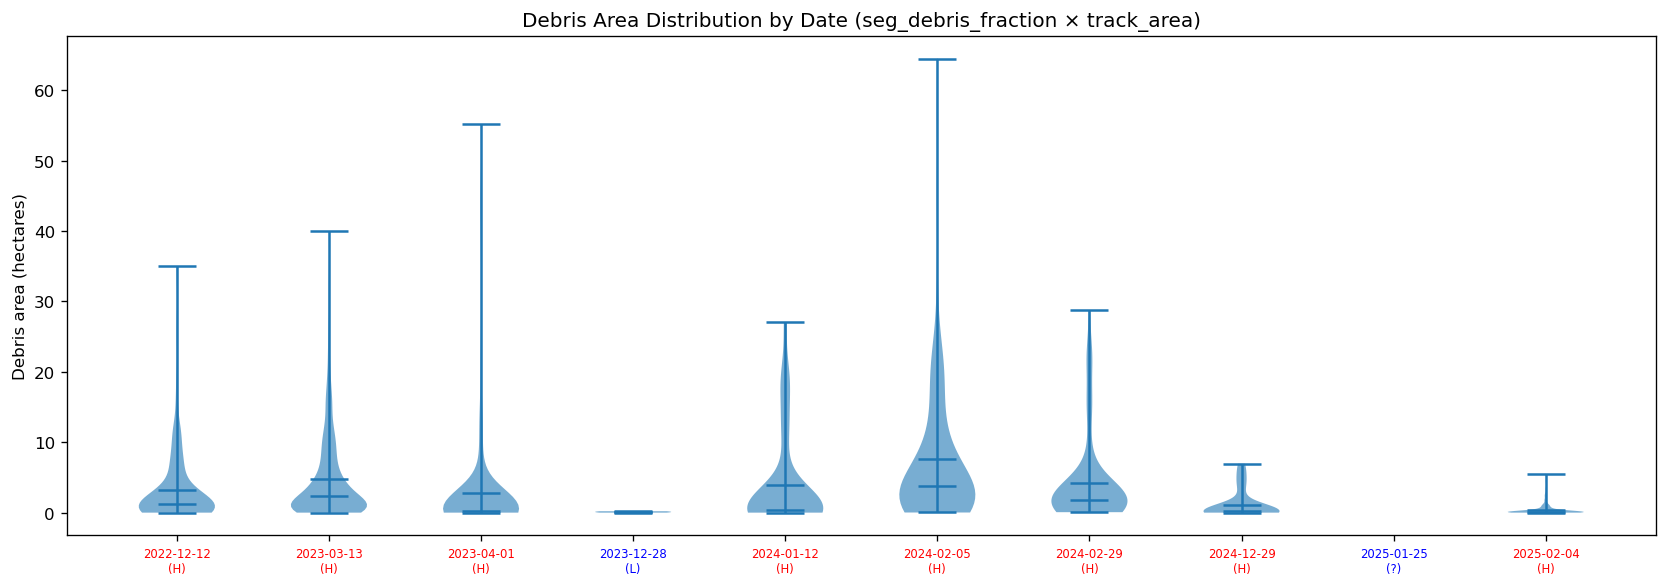

In [5]:
# ── Cell 5: Debris Size Distribution by Date ─────────────────────────────
# Load debris shapes and compute debris area using CNN seg fraction
gdf_debris = gpd.read_file(DEBRIS_GPKG)
gdf_debris['track_area_m2'] = gdf_debris.geometry.area
gdf_debris['date'] = pd.to_datetime(gdf_debris['date'])
gdf_debris['zone_short'] = gdf_debris['zone'].map(ZONE_SHORT)

# Join seg_debris_fraction to get actual debris area within each track
gdf_debris = gdf_debris.merge(
    seg[['seg_debris_fraction']], left_on='key', right_index=True, how='left',
)
gdf_debris['debris_area_m2'] = gdf_debris['seg_debris_fraction'] * gdf_debris['track_area_m2']

print(f'Debris shapes loaded: {len(gdf_debris)}')
print(f'Debris area range: {gdf_debris["debris_area_m2"].min():.0f} – {gdf_debris["debris_area_m2"].max():.0f} m²')

debris_dates = sorted(gdf_debris['date'].unique())

fig, ax = plt.subplots(figsize=(14, 5))
positions = []
data_groups = []
labels = []
tick_colors = []

for j, d in enumerate(debris_dates):
    sub = gdf_debris[gdf_debris['date'] == d]
    danger = df.loc[df['date'] == d, 'danger'].iloc[0] if d in df['date'].values else '?'
    area_ha = sub['debris_area_m2'] / 1e4  # hectares
    data_groups.append(area_ha.values)
    positions.append(j)
    labels.append(f"{d.strftime('%Y-%m-%d')}\n({danger[0]})")
    tick_colors.append('red' if danger == 'HIGH' else 'blue')

parts = ax.violinplot(data_groups, positions=positions, showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_alpha(0.6)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
for ticklabel, c in zip(ax.get_xticklabels(), tick_colors):
    ticklabel.set_color(c)

ax.set_ylabel('Debris area (hectares)')
ax.set_title('Debris Area Distribution by Date (seg_debris_fraction × track_area)')
plt.tight_layout()
plt.show()

Debris tracks with seg features: 78351


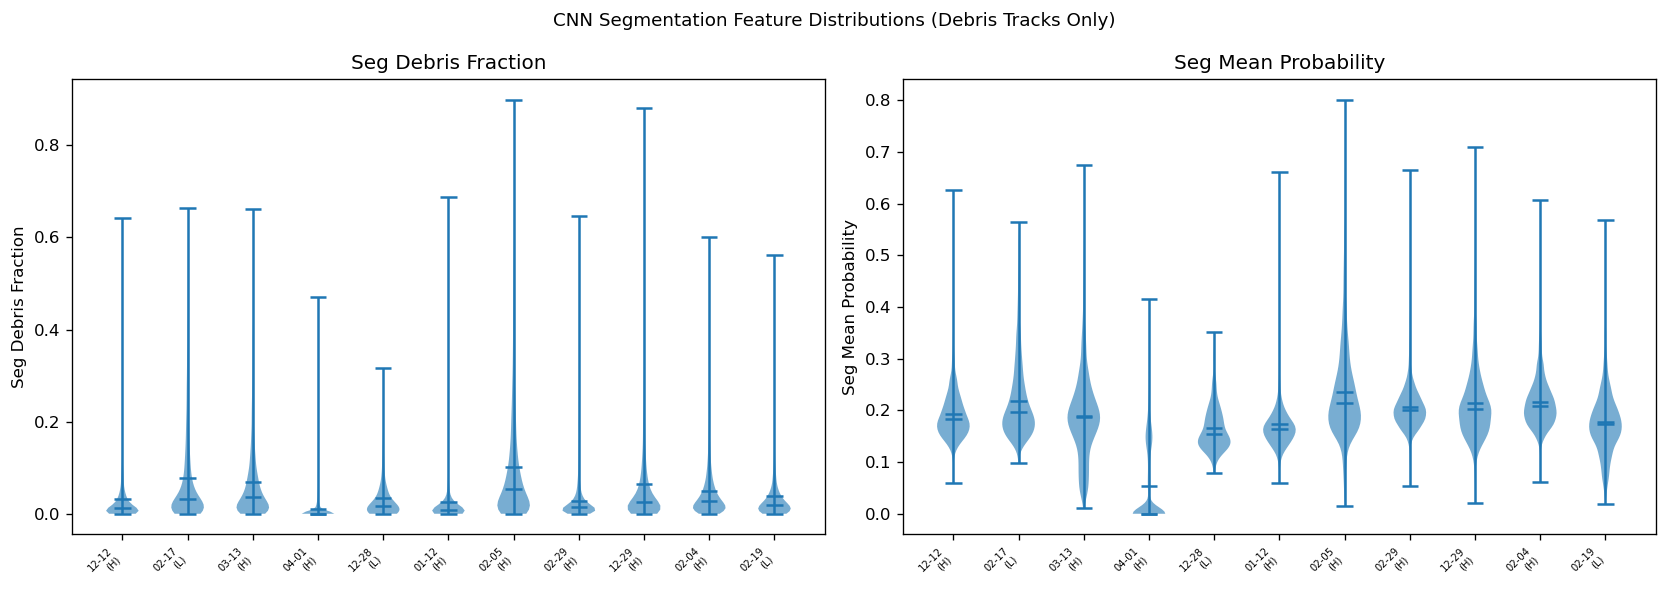

In [6]:
# ── Cell 6: CNN Seg Feature Distributions by Date ────────────────────────
debris_df = df[df['is_debris'] & df['seg_debris_fraction'].notna()].copy()
print(f'Debris tracks with seg features: {len(debris_df)}')

feats = ['seg_debris_fraction', 'seg_mean_prob']
feat_labels = ['Seg Debris Fraction', 'Seg Mean Probability']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, label in zip(axes, feats, feat_labels):
    date_groups = []
    date_labels = []
    for j, d in enumerate(dates):
        sub = debris_df[debris_df['date'] == d]
        if len(sub) == 0:
            continue
        vals = sub[feat].dropna().values
        if len(vals) == 0:
            continue
        date_groups.append(vals)
        danger = sub['danger'].iloc[0]
        date_labels.append(f"{d.strftime('%m-%d')}\n({danger[0]})")

    if date_groups:
        parts = ax.violinplot(date_groups, showmeans=True, showmedians=True)
        for pc in parts['bodies']:
            pc.set_alpha(0.6)
        ax.set_xticks(range(1, len(date_labels) + 1))
        ax.set_xticklabels(date_labels, fontsize=6, rotation=45, ha='right')
    ax.set_title(label)
    ax.set_ylabel(label)

plt.suptitle('CNN Segmentation Feature Distributions (Debris Tracks Only)', fontsize=11)
plt.tight_layout()
plt.show()

Zone: Banner
HIGH danger: 2025-02-04 — 371/644 debris (58%)
LOW danger:  2023-12-28 — 24/644 debris (4%)


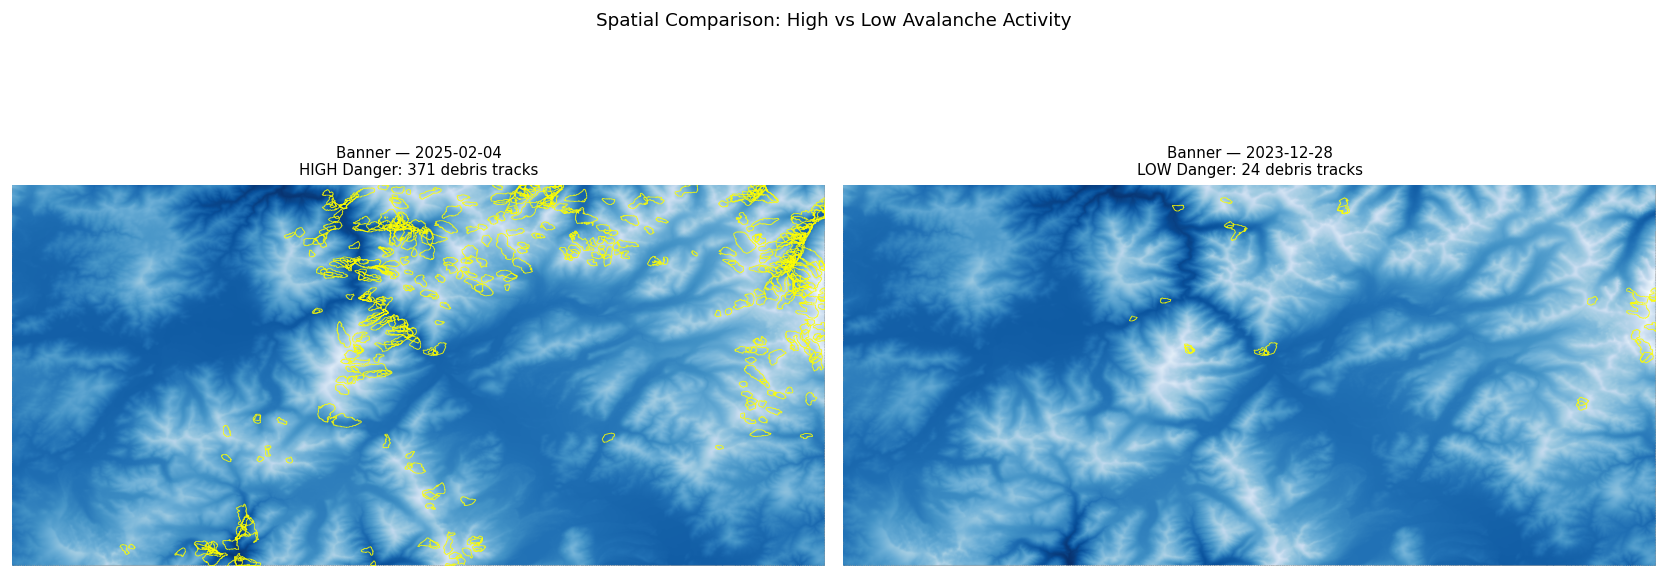

In [16]:
# ── Cell 7: Example Visualizations — High vs Low Activity Dates ──────────
def plot_geom_outline(ax, geom, **kwargs):
    polys = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
    for poly in polys:
        coords = np.array(poly.exterior.coords)
        ax.add_patch(MplPolygon(coords, closed=True, fill=False, **kwargs))

# Discover run files to find matching .nc and .gpkg
nc_lookup = {}   # (zone, date_str) -> nc_path
gpkg_lookup = {} # (zone, date_str) -> gpkg_path
for runs_dir in RUNS_DIRS:
    if not runs_dir.exists():
        continue
    gpkg_paths, nc_paths = _discover_run_files(runs_dir)
    for gp, np_ in zip(gpkg_paths, nc_paths):
        z = zone_from_path(np_)
        d = np_.stem.split('_')[-1]
        nc_lookup[(z, d)] = np_
        gpkg_lookup[(z, d)] = gp

# Pick a HIGH-danger date and a LOW-danger date from the same zone.
# Skip dates with debris_rate > 0.9 — too many outlines obscure the raster.
best_zone = None
best_diff = 0
best_high_date = None
best_low_date = None

for z in zones:
    sub = grp[grp['zone_short'] == z]
    full_z = [k for k, v in ZONE_SHORT.items() if v == z][0]
    high_sub = sub[(sub['danger'] == 'HIGH') & (sub['debris_rate'] <= 0.8)].copy()
    low_sub  = sub[sub['danger'] == 'LOW'].copy()
    # Only consider dates that have .nc files
    high_sub = high_sub[high_sub['date'].apply(lambda d: (full_z, d.strftime('%Y-%m-%d')) in nc_lookup)]
    low_sub  = low_sub[low_sub['date'].apply(lambda d: (full_z, d.strftime('%Y-%m-%d')) in nc_lookup)]
    if high_sub.empty or low_sub.empty:
        continue
    h_row = high_sub.sort_values('n_debris', ascending=False).iloc[0]
    l_row = low_sub.sort_values('n_debris', ascending=True).iloc[0]
    diff = h_row['n_debris'] - l_row['n_debris']
    if diff > best_diff:
        best_diff = diff
        best_zone = z
        best_high_date = h_row['date']
        best_low_date = l_row['date']

#TODO REMOVE THIS
best_zone = 'Banner'
full_zone = [k for k, v in ZONE_SHORT.items() if v == best_zone][0]

high_row = grp[(grp['zone_short'] == best_zone) & (grp['date'] == best_high_date)].iloc[0]
low_row  = grp[(grp['zone_short'] == best_zone) & (grp['date'] == best_low_date)].iloc[0]
print(f'Zone: {best_zone}')
print(f'HIGH danger: {best_high_date.strftime("%Y-%m-%d")} — '
      f'{int(high_row["n_debris"])}/{int(high_row["n_total"])} debris ({high_row["debris_rate"]:.0%})')
print(f'LOW danger:  {best_low_date.strftime("%Y-%m-%d")} — '
      f'{int(low_row["n_debris"])}/{int(low_row["n_total"])} debris ({low_row["debris_rate"]:.0%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, chosen_date, title_suffix in zip(
    axes,
    [best_high_date, best_low_date],
    ['HIGH Danger', 'LOW Danger'],
):
    date_str = chosen_date.strftime('%Y-%m-%d')
    key = (full_zone, date_str)

    if key not in nc_lookup:
        ax.set_title(f'{date_str} — not found')
        continue

    ds = load_netcdf_to_dataset(nc_lookup[key])
    gdf = gpd.read_file(gpkg_lookup[key])

    # Get predictions for this scene
    scene_preds = {k: v for k, v in raw.items() if k.startswith(f'{full_zone}|{date_str}|')}

    # Plot d_empirical full scene
    if 'd_empirical' in ds:
        da = ds['dem']
        arr = da.values
        x_vals = da.x.values
        y_vals = da.y.values
        ax.imshow(
            arr, cmap='Blues_r', #vmin=-3, vmax=3,
            extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
            origin='upper', aspect='equal',
        )

    # Only overlay debris tracks (yellow) to keep the plot readable
    n_deb = 0
    for idx in gdf.index:
        track_key = f'{full_zone}|{date_str}|{idx}'
        pred = scene_preds.get(track_key, {})
        if pred.get('p_debris', 0) >= THRESHOLD:
            n_deb += 1
            geom = reproject_geom(gdf.loc[idx].geometry, gdf.crs, ds.rio.crs)
            plot_geom_outline(ax, geom, edgecolor='yellow', linewidth=0.5, alpha=0.8)

    danger = list(scene_preds.values())[0]['danger'] if scene_preds else '?'
    ax.set_title(f'{best_zone} — {date_str}\n{title_suffix}: {n_deb} debris tracks',
                 fontsize=9)
    ax.axis('off')
    ds.close()

plt.suptitle('Spatial Comparison: High vs Low Avalanche Activity', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 8: Summary Table ────────────────────────────────────────────────
summary = df.groupby(['zone_short', 'date', 'danger']).agg(
    n_tracks=('is_debris', 'size'),
    n_debris=('is_debris', 'sum'),
    debris_rate=('is_debris', 'mean'),
    mean_seg_debris_frac=('seg_debris_fraction', 'mean'),
    median_seg_debris_frac=('seg_debris_fraction', 'median'),
).reset_index()

# Join mean debris area from debris shapes
area_stats = gdf_debris.groupby(['zone_short', 'date']).agg(
    mean_debris_area_m2=('debris_area_m2', 'mean'),
    median_debris_area_m2=('debris_area_m2', 'median'),
).reset_index()
summary = summary.merge(area_stats, on=['zone_short', 'date'], how='left')
summary = summary.sort_values(['date', 'zone_short'])

# Format for display
display_cols = {
    'zone_short': 'Zone',
    'date': 'Date',
    'danger': 'Danger',
    'n_tracks': 'Total Tracks',
    'n_debris': 'Debris Tracks',
    'debris_rate': 'Debris Rate',
    'mean_debris_area_m2': 'Mean Debris Area (m²)',
    'median_seg_debris_frac': 'Median Seg Frac',
}
styled = (
    summary.rename(columns=display_cols)[list(display_cols.values())]
    .style
    .format({
        'Debris Rate': '{:.1%}',
        'Mean Debris Area (m²)': '{:,.0f}',
        'Median Seg Frac': '{:.3f}',
    })
    .background_gradient(subset=['Debris Tracks'], cmap='YlOrRd')
    .background_gradient(subset=['Debris Rate'], cmap='YlOrRd')
)
styled

,Zone,Date,Danger,Total Tracks,Debris Tracks,Debris Rate,Mean Debris Area (m²),Median Seg Frac
0,Banner,2022-12-12 00:00:00,HIGH,644,418,64.9%,"2,405",0.003
11,Galena/East,2022-12-12 00:00:00,HIGH,4570,3681,80.5%,"35,751",0.008
22,Sawtooth/West,2022-12-12 00:00:00,HIGH,3625,2978,82.2%,"14,785",0.008
33,Soldier/Wood,2022-12-12 00:00:00,HIGH,3052,2664,87.3%,"63,724",0.018
1,Banner,2023-02-17 00:00:00,LOW,644,125,19.4%,nan,0.003
12,Galena/East,2023-02-17 00:00:00,LOW,4570,2369,51.8%,nan,0.006
23,Sawtooth/West,2023-02-17 00:00:00,LOW,3625,1707,47.1%,nan,0.009
34,Soldier/Wood,2023-02-17 00:00:00,LOW,3052,2043,66.9%,nan,0.014
2,Banner,2023-03-13 00:00:00,HIGH,644,354,55.0%,"7,234",0.008
13,Galena/East,2023-03-13 00:00:00,HIGH,4570,3152,69.0%,"39,377",0.020
